# Comparison of the SSR setups against the CSR baseline setup

This covers all three setups, and analyses the difference in performance.

In [36]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

path = '../../../../playwright/results/core-web-vitals/testrun-9/'

pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams.update({'font.size': 14})

features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config', 'nf:loaded']

def detect_outliers(df, features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(df[features])
    return outliers == 1

def bootstrap_ci(data1, data2, n_iterations=5000, ci=0.99):
    rng = np.random.default_rng(42)
    diffs = []
    
    for _ in range(n_iterations):
        boot1 = rng.choice(data1, size=len(data1), replace=True)
        boot2 = rng.choice(data2, size=len(data2), replace=True)
        diff = pd.Series(boot1).quantile(0.75) - pd.Series(boot2).quantile(0.75)
        diffs.append(diff)
    
    lower = pd.Series(diffs).quantile((1 - ci) / 2)
    upper = pd.Series(diffs).quantile(1 - ((1 - ci) / 2))
    return lower, upper

## JVM Warmup

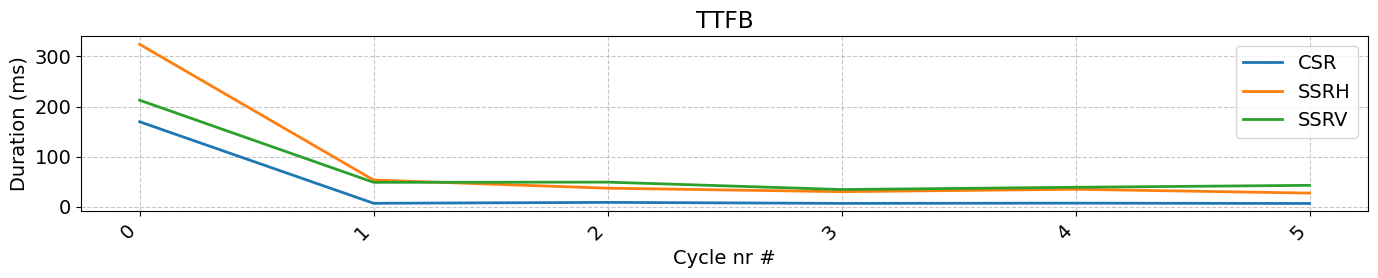

In [37]:
dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr.csv', sep=','),
  "SSRH": pd.read_csv(f'{path}results-ssrh.csv', sep=','),
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd.csv', sep=','),
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 3))

for name, df in dirty_dfs.items():
    ax.plot(df['ttfb'].iloc[:6], 
            label=name, linewidth=2)

ax.set_title("TTFB")
ax.set_xlabel('Cycle nr #')
ax.set_ylabel('Duration (ms)')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## UNTHROTTLED Comparison

The outliers will be removed using the IsolationForest unsupervised model and by removing the first 5 cycles (JVM warmup)

In [38]:
target_features = ['ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [39]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.514e-165,18.00,3.60,14.00,14.80,7.543e-165,True
1,fcp,greater,2.907e-165,96.20,70.90,24.70,25.90,8.722e-165,True
2,lcp,less,2.915e-165,96.20,144.60,-49.20,-47.70,8.745e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [40]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.516e-165,30.50,3.60,26.30,27.52,7.548e-165,True
1,fcp,greater,3.004e-160,86.73,70.90,15.10,17.30,9.012e-160,True
2,lcp,less,5.826e-164,94.62,144.60,-50.93,-49.00,1.748e-163,True


### Comparison of the different metrics

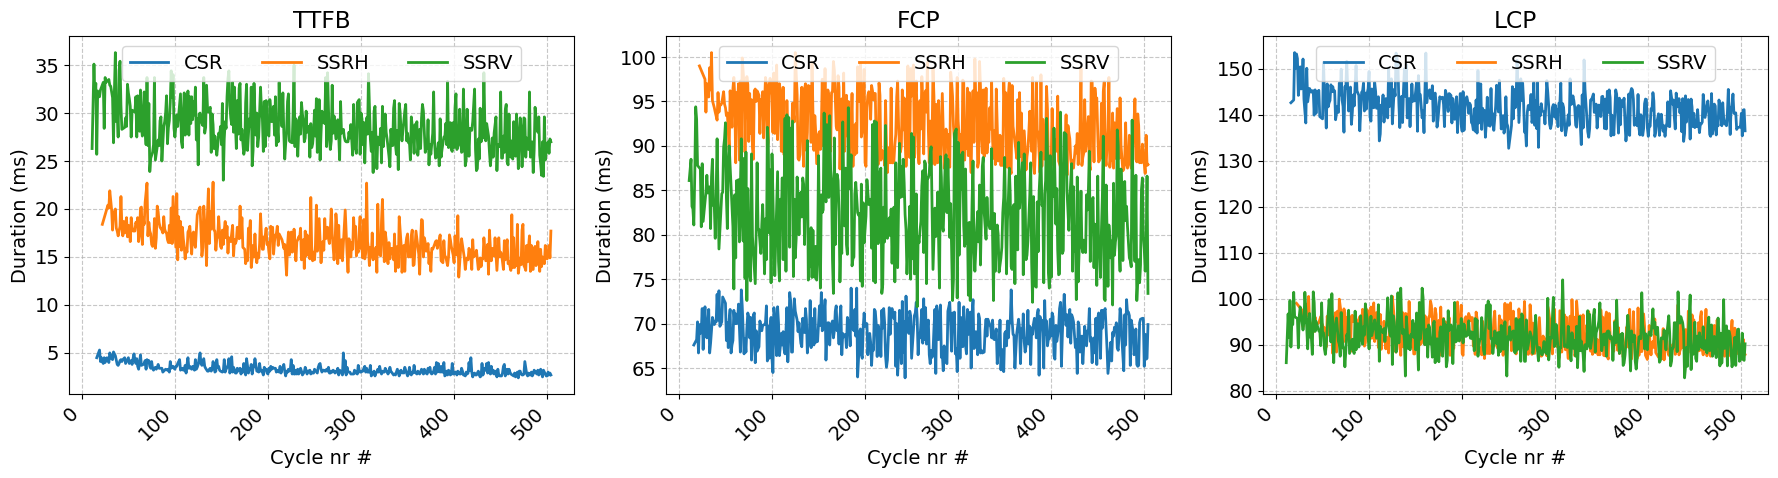

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="upper center", ncols=3)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

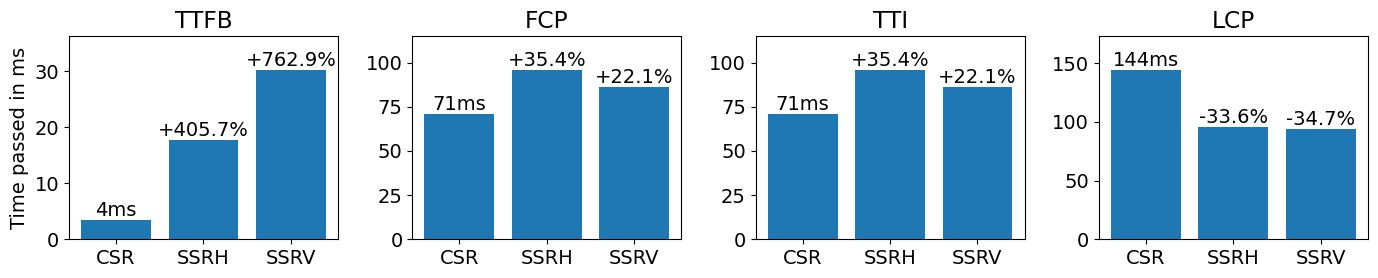

In [42]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(14, 3))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{int(round(bar.get_height(), 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms')

plt.tight_layout()
plt.show()

## THROTTLED Comparison


In [43]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr-throttled.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh-throttled.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd-throttled.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [44]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.622e-165,205.80,176.20,29.40,29.90,7.867e-165,True
1,fcp,greater,2.918e-165,1029.43,970.50,56.50,62.03,8.755e-165,True
2,lcp,less,2.921e-165,1029.43,4411.73,-3385.20,-3378.88,8.764e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [45]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.573e-165,226.60,176.20,50.10,50.60,7.720e-165,True
1,fcp,greater,1.00000,259.83,970.50,-713.20,-708.23,1.00000,False
2,lcp,less,2.924e-165,1047.60,4411.73,-3366.90,-3361.00,8.771e-165,True


### Comparison of the different metrics

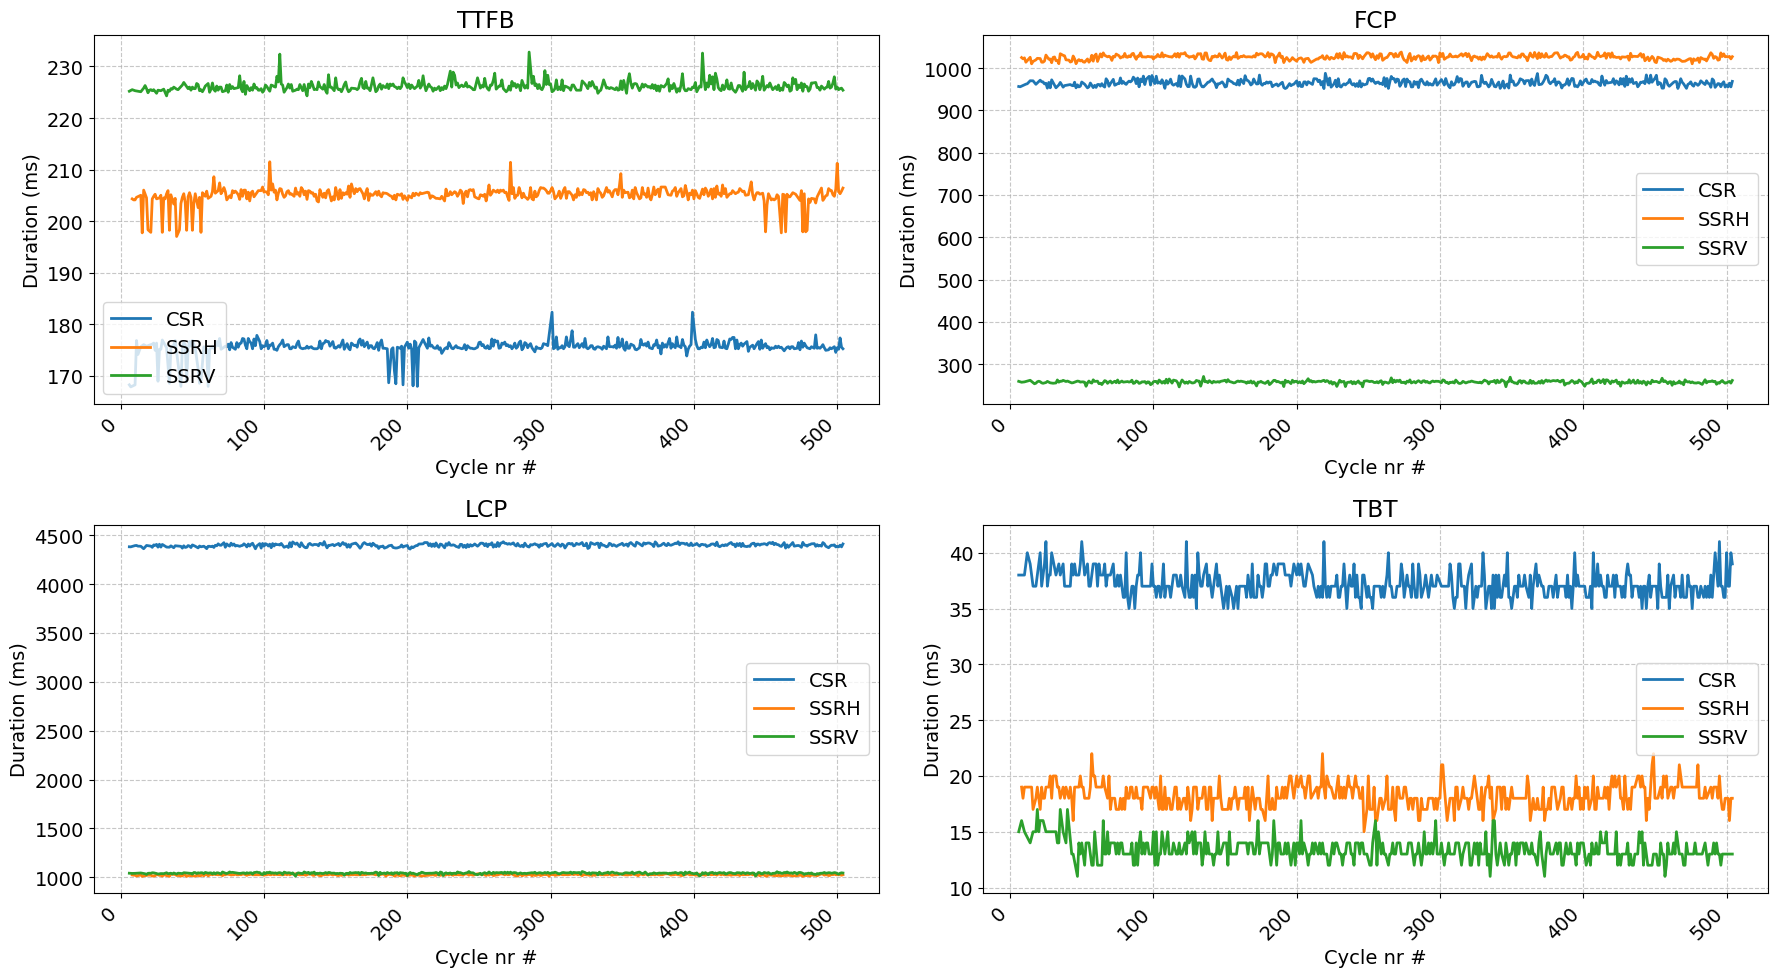

In [46]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18,10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

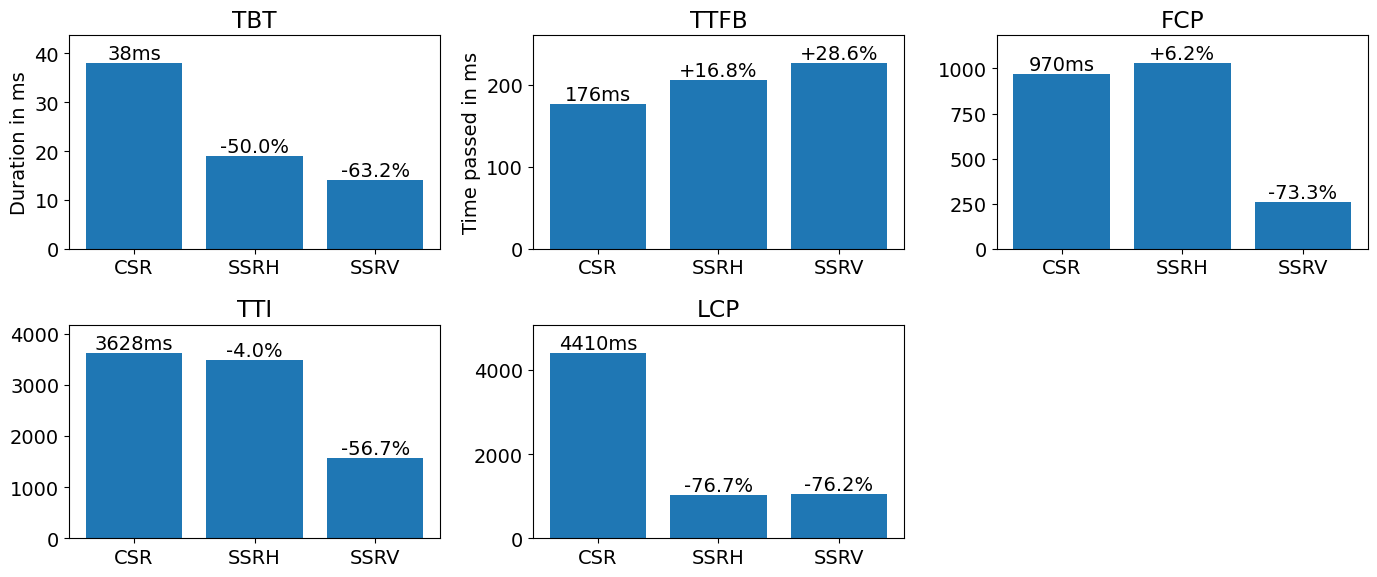

In [47]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
axes = axes.flatten()

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.15)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms')


for ax in axes[len(target_features):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## HEAVY THROTTLED Comparison

In [48]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd-throttled-heavy.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [49]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.799e-165,207.00,178.60,28.22,28.80,8.397e-165,True
1,fcp,greater,2.972e-165,1104.43,1054.63,47.43,51.40,8.915e-165,True
2,lcp,less,2.921e-165,1104.43,4808.07,-3707.73,-3698.40,8.762e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [50]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.734e-165,227.60,178.60,48.90,49.40,8.201e-165,True
1,fcp,greater,1.00000,342.52,1054.63,-715.33,-709.27,1.00000,False
2,lcp,less,2.926e-165,1091.12,4808.07,-3721.37,-3711.27,8.779e-165,True


### Comparing the different metrics


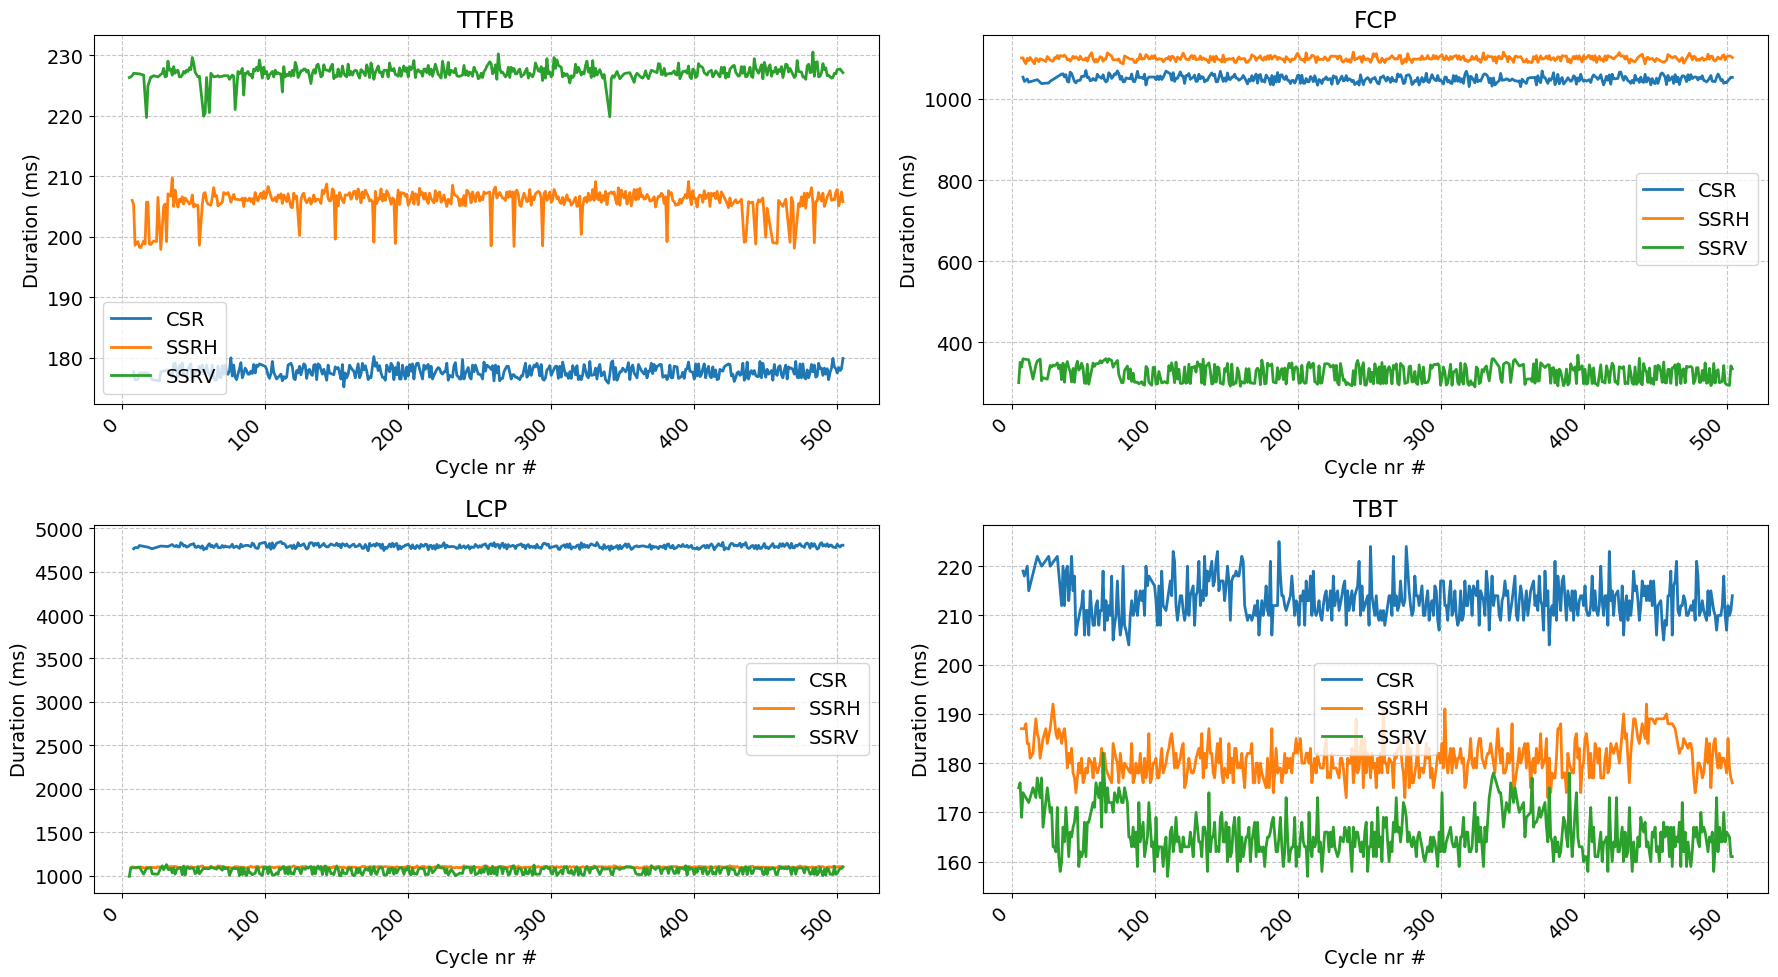

In [51]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

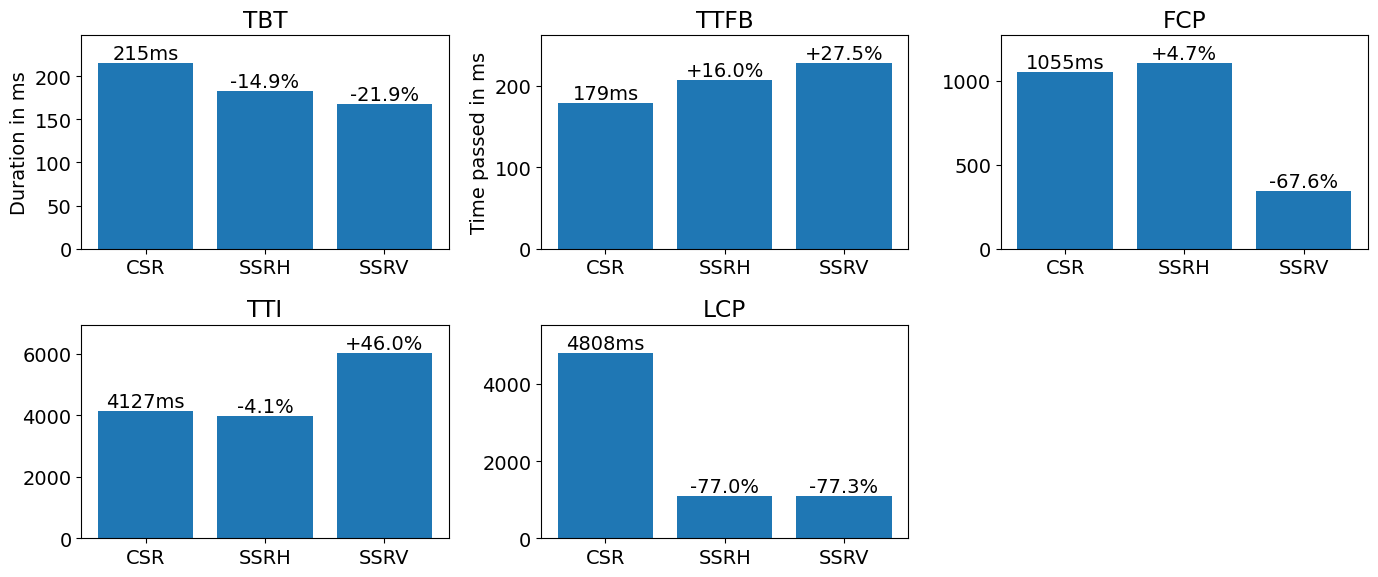

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
axes = axes.flatten()

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.15)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms')


for ax in axes[len(target_features):]:
    ax.axis('off')
plt.tight_layout()
plt.show()